# Chapter 42 — Trace the GT Division Through the Detection Pipeline

This diagnostic notebook traces the known GT division backward through the current pipeline to determine whether the daughter cells were lost during detection, filtering, or tracking.

**Inputs already configured**
- `/kaggle/input/datasets/emailchrismathews/data39`
- `/kaggle/input/datasets/emailchrismathews/data40`
- Biohub competition training data

**Known GT division**
- Parent `172000000050` at `t=66`
- Daughter A `173000000050` at `t=67`
- Daughter B `173000000051` at `t=67`

The notebook searches for Chapter 34/36 outputs automatically and requires the Chapter 37 refined track nodes.


In [1]:
# Install Chapter 42 dependencies
!pip install -q zarr

print("zarr installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 71.7 MB/s eta 0:00:00
zarr installed successfully.


In [2]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from IPython.display import display

warnings.filterwarnings("ignore")

@dataclass(frozen=True)
class Config:
    sample_id: str = "44b6_12dfb391"
    z_scale: float = 1.625
    y_scale: float = 0.40625
    x_scale: float = 0.40625
    trace_start_t: int = 64
    trace_end_t: int = 70
    nearest_k: int = 25
    close_radius_physical: float = 8.0
    loose_radius_physical: float = 15.0

CONFIG = Config()

# ============================================================
# Kaggle input folders
# ============================================================

DATA34_DIR = Path("/kaggle/input/datasets/emailchrismathews/data34")
DATA36_DIR = Path("/kaggle/input/datasets/emailchrismathews/data36")
DATA37_DIR = Path("/kaggle/input/datasets/emailchrismathews/data37")
DATA39_DIR = Path("/kaggle/input/datasets/emailchrismathews/data39")
DATA40_DIR = Path("/kaggle/input/datasets/emailchrismathews/data40")

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Verify attached datasets
# ============================================================

DATA_DIRS = {
    "Chapter 34": DATA34_DIR,
    "Chapter 36": DATA36_DIR,
    "Chapter 37": DATA37_DIR,
    "Chapter 39": DATA39_DIR,
    "Chapter 40": DATA40_DIR,
}

print(CONFIG)
print()
print("=" * 60)
print("KAGGLE INPUT CHECK")
print("=" * 60)

for name, path in DATA_DIRS.items():
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{name:12s}: {status:7s}  {path}")

print()
print("Output directory:", OUTPUT_DIR)


Config(sample_id='44b6_12dfb391', z_scale=1.625, y_scale=0.40625, x_scale=0.40625, trace_start_t=64, trace_end_t=70, nearest_k=25, close_radius_physical=8.0, loose_radius_physical=15.0)

KAGGLE INPUT CHECK
Chapter 34  : FOUND    /kaggle/input/datasets/emailchrismathews/data34
Chapter 36  : FOUND    /kaggle/input/datasets/emailchrismathews/data36
Chapter 37  : FOUND    /kaggle/input/datasets/emailchrismathews/data37
Chapter 39  : FOUND    /kaggle/input/datasets/emailchrismathews/data39
Chapter 40  : FOUND    /kaggle/input/datasets/emailchrismathews/data40

Output directory: /kaggle/working


## Step 1 — Locate and load available pipeline outputs

In [3]:
from pathlib import Path

DATA37_DIR = Path(
    "/kaggle/input/datasets/emailchrismathews/data37"
)

print("Checking:")
print(DATA37_DIR)
print()

if not DATA37_DIR.exists():
    print("DATA37 folder is missing.")
else:
    files = sorted(
        [
            p.name
            for p in DATA37_DIR.iterdir()
            if p.is_file()
        ]
    )

    print("Files found:")
    for name in files:
        print(name)

    print()
    print("Total files:", len(files))

Checking:
/kaggle/input/datasets/emailchrismathews/data37

Files found:
chapter37_refined_track_nodes.csv

Total files: 1


In [4]:
# ============================================================
# STEP 1 — LOCATE AND LOAD AVAILABLE PIPELINE OUTPUTS
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# Explicit Kaggle dataset folders
# ------------------------------------------------------------

DATA34_DIR = Path(
    "/kaggle/input/datasets/emailchrismathews/data34"
)

DATA36_DIR = Path(
    "/kaggle/input/datasets/emailchrismathews/data36"
)

DATA37_DIR = Path(
    "/kaggle/input/datasets/emailchrismathews/data37"
)

DATA39_DIR = Path(
    "/kaggle/input/datasets/emailchrismathews/data39"
)

DATA40_DIR = Path(
    "/kaggle/input/datasets/emailchrismathews/data40"
)

OUTPUT_DIR = Path(
    "/kaggle/working"
)


# ------------------------------------------------------------
# Search roots
# ------------------------------------------------------------

SEARCH_ROOTS = [
    DATA34_DIR,
    DATA36_DIR,
    DATA37_DIR,
    DATA39_DIR,
    DATA40_DIR,
    OUTPUT_DIR,
]


# ------------------------------------------------------------
# File finder
# ------------------------------------------------------------

def find_file(
    filename,
    required=False,
):
    # First try exact filename directly inside each known folder.
    for root in SEARCH_ROOTS:

        if not root.exists():
            continue

        candidate = root / filename

        if candidate.exists():
            return candidate

    # Then search recursively inside each known folder.
    matches = []

    for root in SEARCH_ROOTS:

        if not root.exists():
            continue

        try:
            matches.extend(
                root.rglob(filename)
            )
        except Exception:
            pass

    if matches:

        return sorted(
            matches,
            key=lambda path: len(str(path)),
        )[0]

    if required:

        raise FileNotFoundError(
            f"Could not find required file: {filename}"
        )

    return None


# ------------------------------------------------------------
# Locate pipeline files
# ------------------------------------------------------------

paths = {
    "chapter34_top200":
        find_file(
            "chapter34_top200_detections.csv"
        ),

    "chapter36_filtered":
        find_file(
            "chapter36_filtered_detections.csv"
        ),

    "chapter37_refined":
        find_file(
            "chapter37_refined_track_nodes.csv",
            required=True,
        ),
}


# ------------------------------------------------------------
# Print paths
# ------------------------------------------------------------

print("=" * 80)
print("PIPELINE FILE CHECK")
print("=" * 80)

for name, path in paths.items():

    print(
        f"{name:25s}: "
        f"{path if path is not None else 'NOT FOUND'}"
    )


# ------------------------------------------------------------
# Load available files
# ------------------------------------------------------------

stage_tables = {}


if paths["chapter34_top200"] is not None:

    stage_tables[
        "chapter34_top200"
    ] = pd.read_csv(
        paths["chapter34_top200"]
    )


if paths["chapter36_filtered"] is not None:

    stage_tables[
        "chapter36_filtered"
    ] = pd.read_csv(
        paths["chapter36_filtered"]
    )


stage_tables[
    "chapter37_refined"
] = pd.read_csv(
    paths["chapter37_refined"]
)


# ------------------------------------------------------------
# Confirm loaded tables
# ------------------------------------------------------------

print()
print("=" * 80)
print("LOADED PIPELINE STAGES")
print("=" * 80)

for stage, df in stage_tables.items():

    print(
        f"{stage:25s}: "
        f"{len(df):,} rows"
    )


print()
print("Step 1 complete.")

PIPELINE FILE CHECK
chapter34_top200         : /kaggle/input/datasets/emailchrismathews/data34/chapter34_top200_detections.csv
chapter36_filtered       : /kaggle/input/datasets/emailchrismathews/data36/chapter36_filtered_detections.csv
chapter37_refined        : /kaggle/input/datasets/emailchrismathews/data37/chapter37_refined_track_nodes.csv

LOADED PIPELINE STAGES
chapter34_top200         : 20,000 rows
chapter36_filtered       : 5,000 rows
chapter37_refined        : 4,642 rows

Step 1 complete.


## Step 2 — Load GEFF and identify the true division

In [5]:
def find_geff_path(sample_id):
    expected = Path(
        "/kaggle/input/competitions/biohub-cell-tracking-during-development/train"
    ) / f"{sample_id}.geff"

    if expected.exists():
        return expected

    matches = list(Path("/kaggle/input").rglob(f"{sample_id}.geff"))
    if matches:
        return sorted(matches, key=lambda p: len(str(p)))[0]

    raise FileNotFoundError(f"Could not find GEFF file for {sample_id}")

geff_path = find_geff_path(CONFIG.sample_id)
geff = zarr.open(geff_path, mode="r")

gt_nodes_df = pd.DataFrame({
    "gt_node_id": np.asarray(geff["nodes/ids"][:]),
    "t": np.asarray(geff["nodes/props/t/values"][:]).astype(int),
    "z": np.asarray(geff["nodes/props/z/values"][:]).astype(float),
    "y": np.asarray(geff["nodes/props/y/values"][:]).astype(float),
    "x": np.asarray(geff["nodes/props/x/values"][:]).astype(float),
})

edge_ids = np.asarray(geff["edges/ids"][:])
gt_edges_df = pd.DataFrame({
    "gt_source": edge_ids[:, 0],
    "gt_target": edge_ids[:, 1],
})

out_degree = gt_edges_df.groupby("gt_source").size()
division_parents = out_degree[out_degree == 2].index.tolist()

division_rows = []
for parent in division_parents:
    daughters = sorted(
        gt_edges_df.loc[gt_edges_df["gt_source"] == parent, "gt_target"].tolist()
    )
    if len(daughters) != 2:
        continue

    p = gt_nodes_df[gt_nodes_df["gt_node_id"] == parent]
    a = gt_nodes_df[gt_nodes_df["gt_node_id"] == daughters[0]]
    b = gt_nodes_df[gt_nodes_df["gt_node_id"] == daughters[1]]

    if p.empty or a.empty or b.empty:
        continue

    p, a, b = p.iloc[0], a.iloc[0], b.iloc[0]

    division_rows.append({
        "gt_parent": parent,
        "gt_daughter_a": daughters[0],
        "gt_daughter_b": daughters[1],
        "parent_t": int(p["t"]),
        "daughter_t_a": int(a["t"]),
        "daughter_t_b": int(b["t"]),
        "parent_z": float(p["z"]), "parent_y": float(p["y"]), "parent_x": float(p["x"]),
        "daughter_a_z": float(a["z"]), "daughter_a_y": float(a["y"]), "daughter_a_x": float(a["x"]),
        "daughter_b_z": float(b["z"]), "daughter_b_y": float(b["y"]), "daughter_b_x": float(b["x"]),
    })

gt_divisions_df = pd.DataFrame(division_rows)

if gt_divisions_df.empty:
    raise RuntimeError("No GT division found.")

division = gt_divisions_df.iloc[0]

print("GEFF:", geff_path)
print("GT nodes:", len(gt_nodes_df), "GT edges:", len(gt_edges_df))
display(gt_divisions_df)


GEFF: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_12dfb391.geff
GT nodes: 788 GT edges: 773


,gt_parent,gt_daughter_a,gt_daughter_b,parent_t,daughter_t_a,daughter_t_b,parent_z,parent_y,parent_x,daughter_a_z,daughter_a_y,daughter_a_x,daughter_b_z,daughter_b_y,daughter_b_x
0,172000000050,173000000050,173000000051,66,67,67,46.0,63.0,160.0,46.0,51.0,160.0,46.0,74.0,164.0


## Step 3 — Add physical coordinates and build GT role table

In [6]:
def add_physical_coordinates(df):
    result = df.copy()
    result["z_physical"] = result["z"].astype(float) * CONFIG.z_scale
    result["y_physical"] = result["y"].astype(float) * CONFIG.y_scale
    result["x_physical"] = result["x"].astype(float) * CONFIG.x_scale
    return result

for stage in list(stage_tables.keys()):
    stage_tables[stage] = add_physical_coordinates(stage_tables[stage])

gt_role_df = pd.DataFrame([
    {
        "role": "parent",
        "gt_node_id": division["gt_parent"],
        "t": int(division["parent_t"]),
        "z": float(division["parent_z"]),
        "y": float(division["parent_y"]),
        "x": float(division["parent_x"]),
    },
    {
        "role": "daughter_a",
        "gt_node_id": division["gt_daughter_a"],
        "t": int(division["daughter_t_a"]),
        "z": float(division["daughter_a_z"]),
        "y": float(division["daughter_a_y"]),
        "x": float(division["daughter_a_x"]),
    },
    {
        "role": "daughter_b",
        "gt_node_id": division["gt_daughter_b"],
        "t": int(division["daughter_t_b"]),
        "z": float(division["daughter_b_z"]),
        "y": float(division["daughter_b_y"]),
        "x": float(division["daughter_b_x"]),
    },
])

gt_role_df = add_physical_coordinates(gt_role_df)
display(gt_role_df)


,role,gt_node_id,t,z,y,x,z_physical,y_physical,x_physical
0,parent,1.720000e+11,66,46.0,63.0,160.0,74.75,25.59375,65.000
1,daughter_a,1.730000e+11,67,46.0,51.0,160.0,74.75,20.71875,65.000
2,daughter_b,1.730000e+11,67,46.0,74.0,164.0,74.75,30.06250,66.625


## Step 4 — Find nearest detections at the exact GT frame

Interpretation:
- no close Chapter 34 detection → detector recall problem
- close Chapter 34 but not Chapter 36 → filtering loss
- close Chapter 36 but not Chapter 37 → tracking/refinement loss


In [7]:
def nearest_at_exact_frame(table, stage, role_row):
    same_t = table[table["t"].astype(int) == int(role_row["t"])].copy()

    if same_t.empty:
        return pd.DataFrame()

    gt_xyz = np.array([
        role_row["z_physical"],
        role_row["y_physical"],
        role_row["x_physical"],
    ])

    pred_xyz = same_t[
        ["z_physical", "y_physical", "x_physical"]
    ].to_numpy(dtype=float)

    same_t["distance_to_gt_physical"] = np.linalg.norm(
        pred_xyz - gt_xyz[None, :],
        axis=1,
    )

    same_t["stage"] = stage
    same_t["role"] = role_row["role"]
    same_t["gt_node_id"] = role_row["gt_node_id"]
    same_t["within_close_radius"] = (
        same_t["distance_to_gt_physical"] <= CONFIG.close_radius_physical
    )
    same_t["within_loose_radius"] = (
        same_t["distance_to_gt_physical"] <= CONFIG.loose_radius_physical
    )

    return (
        same_t
        .sort_values("distance_to_gt_physical")
        .head(CONFIG.nearest_k)
        .reset_index(drop=True)
    )

nearest_tables = []

for stage, table in stage_tables.items():
    for _, role_row in gt_role_df.iterrows():
        result = nearest_at_exact_frame(table, stage, role_row)
        if not result.empty:
            nearest_tables.append(result)

nearest_detections_df = (
    pd.concat(nearest_tables, ignore_index=True)
    if nearest_tables
    else pd.DataFrame()
)

summary_rows = []

for stage in stage_tables:
    for role in gt_role_df["role"]:
        subset = nearest_detections_df[
            (nearest_detections_df["stage"] == stage)
            & (nearest_detections_df["role"] == role)
        ]

        summary_rows.append({
            "stage": stage,
            "role": role,
            "nearest_distance_physical": (
                float(subset["distance_to_gt_physical"].min())
                if not subset.empty
                else np.nan
            ),
            "close_candidates": (
                int(subset["within_close_radius"].sum())
                if not subset.empty
                else 0
            ),
            "loose_candidates": (
                int(subset["within_loose_radius"].sum())
                if not subset.empty
                else 0
            ),
        })

exact_frame_summary_df = pd.DataFrame(summary_rows)
display(exact_frame_summary_df)


,stage,role,nearest_distance_physical,close_candidates,loose_candidates
0,chapter34_top200,parent,13.626039,0,2
1,chapter34_top200,daughter_a,9.992429,0,1
2,chapter34_top200,daughter_b,15.178753,0,0
3,chapter36_filtered,parent,13.626039,0,2
4,chapter36_filtered,daughter_a,20.686863,0,0
5,chapter36_filtered,daughter_b,15.597037,0,0
6,chapter37_refined,parent,13.626039,0,2
7,chapter37_refined,daughter_a,20.686863,0,0
8,chapter37_refined,daughter_b,15.597037,0,0


## Step 5 — Trace the full division window t=64..70

In [8]:
def nearest_over_window(table, stage, role_row):
    local = table[
        table["t"].between(CONFIG.trace_start_t, CONFIG.trace_end_t)
    ].copy()

    if local.empty:
        return pd.DataFrame()

    gt_xyz = np.array([
        role_row["z_physical"],
        role_row["y_physical"],
        role_row["x_physical"],
    ])

    pred_xyz = local[
        ["z_physical", "y_physical", "x_physical"]
    ].to_numpy(dtype=float)

    local["distance_to_gt_physical"] = np.linalg.norm(
        pred_xyz - gt_xyz[None, :],
        axis=1,
    )

    local["temporal_gap"] = (
        local["t"].astype(int) - int(role_row["t"])
    ).abs()

    local["trace_score"] = (
        local["distance_to_gt_physical"]
        + 2.0 * local["temporal_gap"]
    )

    local["stage"] = stage
    local["role"] = role_row["role"]

    return (
        local
        .sort_values(["trace_score", "distance_to_gt_physical"])
        .head(CONFIG.nearest_k)
        .reset_index(drop=True)
    )

window_tables = []

for stage, table in stage_tables.items():
    for _, role_row in gt_role_df.iterrows():
        result = nearest_over_window(table, stage, role_row)
        if not result.empty:
            window_tables.append(result)

window_trace_df = (
    pd.concat(window_tables, ignore_index=True)
    if window_tables
    else pd.DataFrame()
)

window_summary_rows = []

for stage in stage_tables:
    for role in gt_role_df["role"]:
        subset = window_trace_df[
            (window_trace_df["stage"] == stage)
            & (window_trace_df["role"] == role)
        ]

        if subset.empty:
            window_summary_rows.append({
                "stage": stage,
                "role": role,
                "best_t": np.nan,
                "best_distance_physical": np.nan,
                "best_temporal_gap": np.nan,
            })
        else:
            best = subset.iloc[0]
            window_summary_rows.append({
                "stage": stage,
                "role": role,
                "best_t": int(best["t"]),
                "best_distance_physical": float(best["distance_to_gt_physical"]),
                "best_temporal_gap": int(best["temporal_gap"]),
            })

window_summary_df = pd.DataFrame(window_summary_rows)
display(window_summary_df)


,stage,role,best_t,best_distance_physical,best_temporal_gap
0,chapter34_top200,parent,65,9.622209,1
1,chapter34_top200,daughter_a,68,6.563170,1
2,chapter34_top200,daughter_b,68,6.749132,1
3,chapter36_filtered,parent,66,13.626039,0
4,chapter36_filtered,daughter_a,66,15.781126,1
5,chapter36_filtered,daughter_b,66,11.788252,1
6,chapter37_refined,parent,66,13.626039,0
7,chapter37_refined,daughter_a,66,15.781126,1
8,chapter37_refined,daughter_b,66,11.788252,1


## Step 6 — Inspect the nearest Chapter 37 daughter tracks

In [9]:
refined_df = stage_tables["chapter37_refined"].copy()

daughter_rows = []

for role in ["daughter_a", "daughter_b"]:
    subset = window_trace_df[
        (window_trace_df["stage"] == "chapter37_refined")
        & (window_trace_df["role"] == role)
    ].copy()

    if subset.empty or "track_id" not in subset.columns:
        continue

    for track_id in subset["track_id"].dropna().astype(int).unique():
        track = refined_df[
            refined_df["track_id"] == track_id
        ].sort_values("t")

        relevant = subset[
            subset["track_id"].astype(int) == track_id
        ].sort_values("trace_score")

        role_gt_t = int(
            gt_role_df.loc[
                gt_role_df["role"] == role,
                "t",
            ].iloc[0]
        )

        daughter_rows.append({
            "role": role,
            "track_id": track_id,
            "track_start_t": int(track["t"].min()),
            "track_end_t": int(track["t"].max()),
            "track_length": len(track),
            "nearest_t_to_gt": int(relevant.iloc[0]["t"]),
            "nearest_distance_physical": float(
                relevant.iloc[0]["distance_to_gt_physical"]
            ),
            "started_before_division": int(track["t"].min()) < role_gt_t,
            "started_at_or_after_division": int(track["t"].min()) >= role_gt_t,
            "mean_rank": (
                float(track["rank_position"].mean())
                if "rank_position" in track.columns
                else np.nan
            ),
            "mean_pred_dist": (
                float(track["pred_dist"].mean())
                if "pred_dist" in track.columns
                else np.nan
            ),
        })

daughter_track_diagnostics_df = (
    pd.DataFrame(daughter_rows)
    .sort_values(["role", "nearest_distance_physical"])
    .reset_index(drop=True)
    if daughter_rows
    else pd.DataFrame()
)

display(daughter_track_diagnostics_df.head(50))


,role,track_id,track_start_t,track_end_t,track_length,nearest_t_to_gt,nearest_distance_physical,started_before_division,started_at_or_after_division,mean_rank,mean_pred_dist
0,daughter_a,196,22,70,30,64,13.063322,True,False,51.766667,15.350907
1,daughter_a,313,54,83,16,66,15.781126,True,False,51.000000,15.761184
2,daughter_a,432,70,97,12,70,15.947576,False,True,59.000000,15.354942
3,daughter_a,324,51,66,8,66,16.436817,True,False,29.875000,15.492934
4,daughter_a,131,17,64,15,64,16.531929,True,False,71.000000,16.253565
5,daughter_a,312,47,66,14,66,16.975223,True,False,66.642857,15.870508
6,daughter_a,405,66,82,10,66,17.445115,True,False,90.600000,16.494798
7,daughter_a,379,61,73,5,68,20.446123,True,False,67.400000,16.575979
8,daughter_a,403,65,67,2,67,20.686863,True,False,25.000000,15.549768
9,daughter_a,197,22,66,12,66,25.125175,True,False,55.166667,16.319822


## Step 7 — Automatic stage diagnosis

In [10]:
def exact_distance(stage, role):
    row = exact_frame_summary_df[
        (exact_frame_summary_df["stage"] == stage)
        & (exact_frame_summary_df["role"] == role)
    ]

    if row.empty:
        return np.nan

    return float(row.iloc[0]["nearest_distance_physical"])

diagnosis_rows = []

for role in ["daughter_a", "daughter_b"]:
    d34 = (
        exact_distance("chapter34_top200", role)
        if "chapter34_top200" in stage_tables
        else np.nan
    )
    d36 = (
        exact_distance("chapter36_filtered", role)
        if "chapter36_filtered" in stage_tables
        else np.nan
    )
    d37 = exact_distance("chapter37_refined", role)

    if not np.isnan(d34):
        if d34 > CONFIG.loose_radius_physical:
            diagnosis = "Likely detector recall problem: Chapter 34 has no close detection."
        elif not np.isnan(d36) and d36 > CONFIG.loose_radius_physical:
            diagnosis = "Likely filtering loss: Chapter 34 is close but Chapter 36 is not."
        elif d37 > CONFIG.loose_radius_physical:
            diagnosis = "Likely tracking/refinement loss: earlier stage is close but Chapter 37 is not."
        else:
            diagnosis = "Spatial detection survives; likely track-start/timing or fragmentation problem."
    else:
        diagnosis = (
            "Chapter 34 output unavailable; diagnose using Chapter 37 timing "
            "and attach Chapter 34/36 outputs for full trace."
        )

    diagnosis_rows.append({
        "role": role,
        "chapter34_distance": d34,
        "chapter36_distance": d36,
        "chapter37_distance": d37,
        "diagnosis": diagnosis,
    })

diagnosis_df = pd.DataFrame(diagnosis_rows)
display(diagnosis_df)


,role,chapter34_distance,chapter36_distance,chapter37_distance,diagnosis
0,daughter_a,9.992429,20.686863,20.686863,Likely filtering loss: Chapter 34 is close but...
1,daughter_b,15.178753,15.597037,15.597037,Likely detector recall problem: Chapter 34 has...


## Step 8 — Visualize nearby refined tracks

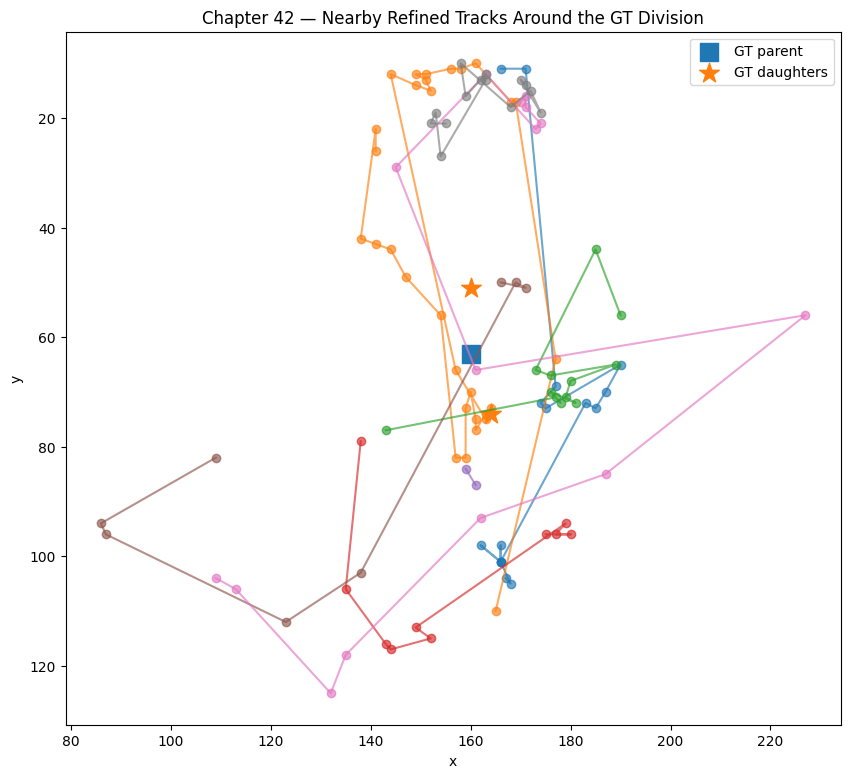

In [11]:
plt.figure(figsize=(10, 9))

plt.scatter(
    [division["parent_x"]],
    [division["parent_y"]],
    marker="s",
    s=160,
    label="GT parent",
)

plt.scatter(
    [division["daughter_a_x"], division["daughter_b_x"]],
    [division["daughter_a_y"], division["daughter_b_y"]],
    marker="*",
    s=220,
    label="GT daughters",
)

if not daughter_track_diagnostics_df.empty:
    nearest_tracks = (
        daughter_track_diagnostics_df
        .sort_values("nearest_distance_physical")
        .head(12)
    )

    for track_id in nearest_tracks["track_id"].astype(int).unique():
        track = refined_df[
            refined_df["track_id"] == track_id
        ].sort_values("t")

        plt.plot(
            track["x"],
            track["y"],
            marker="o",
            alpha=0.65,
        )

plt.gca().invert_yaxis()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Chapter 42 — Nearby Refined Tracks Around the GT Division")
plt.legend()
plt.show()


## Step 9 — Save diagnostic outputs

In [12]:
trace_summary_df = pd.merge(
    exact_frame_summary_df,
    window_summary_df,
    on=["stage", "role"],
    how="outer",
)

validation_df = pd.DataFrame([
    {
        "check": "gt_division_found",
        "passed": len(gt_divisions_df) > 0,
        "details": f"{len(gt_divisions_df)} GT division(s)",
    },
    {
        "check": "chapter37_loaded",
        "passed": "chapter37_refined" in stage_tables,
        "details": f"{len(refined_df)} rows",
    },
    {
        "check": "daughter_a_trace_created",
        "passed": (
            not window_trace_df.empty
            and (window_trace_df["role"] == "daughter_a").any()
        ),
        "details": "division window inspected",
    },
    {
        "check": "daughter_b_trace_created",
        "passed": (
            not window_trace_df.empty
            and (window_trace_df["role"] == "daughter_b").any()
        ),
        "details": "division window inspected",
    },
])

outputs = {
    "chapter42_gt_division_trace_summary.csv": trace_summary_df,
    "chapter42_nearest_detections_by_stage.csv": nearest_detections_df,
    "chapter42_division_window_trace.csv": window_trace_df,
    "chapter42_daughter_track_diagnostics.csv": daughter_track_diagnostics_df,
    "chapter42_stage_diagnosis.csv": diagnosis_df,
    "chapter42_gt_division.csv": gt_divisions_df,
    "chapter42_output_validation.csv": validation_df,
}

for filename, df in outputs.items():
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    print("Saved:", path, "| rows:", len(df))

zip_path = shutil.make_archive(
    str(OUTPUT_DIR / "chapter42_outputs"),
    "zip",
    root_dir=OUTPUT_DIR,
    base_dir=".",
)

print()
print("Created ZIP:", zip_path)

verification_df = pd.DataFrame([
    {
        "filename": p.name,
        "size_bytes": p.stat().st_size,
        "exists": p.exists(),
    }
    for p in sorted(OUTPUT_DIR.glob("chapter42_*"))
])

display(validation_df)
display(verification_df)


Saved: /kaggle/working/chapter42_gt_division_trace_summary.csv | rows: 9
Saved: /kaggle/working/chapter42_nearest_detections_by_stage.csv | rows: 225
Saved: /kaggle/working/chapter42_division_window_trace.csv | rows: 225
Saved: /kaggle/working/chapter42_daughter_track_diagnostics.csv | rows: 26
Saved: /kaggle/working/chapter42_stage_diagnosis.csv | rows: 2
Saved: /kaggle/working/chapter42_gt_division.csv | rows: 1
Saved: /kaggle/working/chapter42_output_validation.csv | rows: 4

Created ZIP: /kaggle/working/chapter42_outputs.zip


,check,passed,details
0,gt_division_found,True,1 GT division(s)
1,chapter37_loaded,True,4642 rows
2,daughter_a_trace_created,True,division window inspected
3,daughter_b_trace_created,True,division window inspected


,filename,size_bytes,exists
0,chapter42_daughter_track_diagnostics.csv,2305,True
1,chapter42_division_window_trace.csv,143221,True
2,chapter42_gt_division.csv,274,True
3,chapter42_gt_division_trace_summary.csv,784,True
4,chapter42_nearest_detections_by_stage.csv,143535,True
5,chapter42_output_validation.csv,205,True
6,chapter42_outputs.zip,179952,True
7,chapter42_stage_diagnosis.csv,337,True


# Chapter 42 Complete

The most important output is `chapter42_stage_diagnosis.csv`.

Use the results to decide the next lesson:

- **Detector recall problem** → improve Chapter 34 candidate recall near divisions.
- **Filtering loss** → redesign Chapter 36 track-aware filtering around division events.
- **Tracking/refinement loss** → split/branch tracks around mitosis.
- **Track-start/timing problem** → build division-aware track splitting before division classification.

Save `chapter42_outputs.zip`.
